In [16]:
# ============================================================
#  Concave partitions — everything concave_hull(lam, plot=False) needs.
#  (Plotting helpers _plot_partition / plot_all are omitted: not reached
#   when plot=False.)
# ============================================================

try:
    from sage.all import Polyhedron
except ImportError:
    from sage.geometry.polyhedron.constructor import Polyhedron


# ── helpers ─────────────────────────────────────────────────

def _row_len(lam, r):
    r = int(r)
    if 1 <= r <= len(lam):
        return int(lam[r - 1])
    return 0

def _in_lam(lam, c, r):
    c, r = int(c), int(r)
    if not (1 <= r <= len(lam)):
        return False
    return 1 <= c <= int(lam[r - 1])

def _touches8(lam, c, r):
    c, r = int(c), int(r)
    for dc in [-1, 0, 1]:
        for dr in [-1, 0, 1]:
            if dc == 0 and dr == 0:
                continue
            if _in_lam(lam, c + dc, r + dr):
                return True
    return False

def _qualifying_boxes(lam):
    max_col = int(max(lam)) + 3
    max_row = int(len(lam)) + 3
    result = []
    for c in range(2, max_col + 1):
        for r in range(2, max_row + 1):
            if not _in_lam(lam, c, r) and not _touches8(lam, c, r):
                result.append((c, r))
    result.sort()
    return result

def _finite_vertices(lam):
    """
    Return (finite_verts, ll_ieqs) for the unbounded convex hull.

    Sage inequality [b, a0, a1] means a0*x + a1*y + b >= 0.
    Outward normal of the feasible region is (-a0, -a1).
    Lower-left-facing facet (outward normal points SW): a0 > 0 and a1 > 0.

    ll_ieqs entries are (a0, a1, b) with a0*x + a1*y + b >= 0, a0 > 0, a1 > 0.
    """
    cands = _qualifying_boxes(lam)
    if not cands:
        return [], []

    ll_corners = list(set((c - 1, r - 1) for c, r in cands))
    P = Polyhedron(vertices=ll_corners)

    ll_ieqs = []
    for ieq in P.inequalities():
        b  = QQ(ieq[0])
        a0 = QQ(ieq[1])
        a1 = QQ(ieq[2])
        if a0 > 0 and a1 > 0:          # <-- lower-left-facing: outward normal (-a0,-a1) is SW
            ll_ieqs.append((a0, a1, b))

    finite_verts = set()
    for v in P.vertices():
        x = QQ(v[0])
        y = QQ(v[1])
        for (a0, a1, b) in ll_ieqs:
            if a0 * x + a1 * y + b == 0:
                finite_verts.add((x, y))
                break

    finite_verts = sorted((ZZ(x), ZZ(y)) for x, y in finite_verts)
    return finite_verts, ll_ieqs

def _in_hull(ll_ieqs, x, y):
    """
    True iff (x, y) is in the unbounded hull (boundary included).
    The unbounded hull satisfies exactly the lower-left-facing constraints.
    """
    x, y = QQ(x), QQ(y)
    for (a0, a1, b) in ll_ieqs:
        if a0 * x + a1 * y + b < 0:
            return False
    return True


def _boundary_curve(finite_verts):
    """
    Boundary polyline of the unbounded hull, ordered y-axis -> x-axis.

    Returns (curve, y_left, x_bot) where curve is a list of (QQ, QQ)
    points: the y-axis intercept, the finite vertices, then the x-axis
    intercept.  The first/last facets are extended to the axes.
    """
    v = [(QQ(x), QQ(y)) for x, y in finite_verts]
    if len(v) >= 2:
        m0     = (v[1][1] - v[0][1]) / (v[1][0] - v[0][0])
        y_left = v[0][1] - m0 * v[0][0]                                   # hits x = 0
        m_last = (v[-1][1] - v[-2][1]) / (v[-1][0] - v[-2][0])
        x_bot  = v[-1][0] - v[-1][1] / m_last if m_last != 0 else v[-1][0]  # hits y = 0
    else:
        # single hull vertex: the boundary is a right-angle corner
        y_left = v[0][1]
        x_bot  = v[0][0]
    return [(QQ(0), y_left)] + v + [(x_bot, QQ(0))], y_left, x_bot


# ── main function ────────────────────────────────────────────

def concave_hull(lam, plot=True, size=1, verbose=True):
    """
    Analyze a partition and, if plot=True, draw and display it.

    Computes the unbounded convex hull of the qualifying outside boxes,
    its boundary curve (y-axis -> x-axis), and whether lam is concave.

    Returns a details dict carrying everything the overlay needs:
        lam          : the partition (list)
        is_concave   : bool, or None when there are no qualifying boxes
        finite_verts : finite vertices of the hull
        ll_ieqs      : lower-left-facing inequalities (a0, a1, b)
        curve        : boundary polyline [(QQ, QQ), ...], y-axis -> x-axis
                       ([] when there are no qualifying boxes)
        y_left, x_bot: where the curve meets the y- and x-axes (or None)
        plot         : Graphics object, or None when plot=False

    With plot=True the figure is shown immediately; the details dict is
    still returned (assign it, e.g. d = concave_hull(...), to keep it
    without echoing the dict).
    """
    lam = list(lam)
    details = dict(lam=lam, is_concave=None, finite_verts=[], ll_ieqs=[],
                   curve=[], y_left=None, x_bot=None, plot=None)

    if not lam:
        if verbose:
            print("Empty partition.")
        return details

    finite_verts, ll_ieqs = _finite_vertices(lam)
    details['finite_verts'] = finite_verts
    details['ll_ieqs']      = ll_ieqs

    if finite_verts:
        # boundary curve
        curve, y_left, x_bot = _boundary_curve(finite_verts)
        details.update(curve=curve, y_left=y_left, x_bot=x_bot)

        # boxes of lam (French notation)
        lam_boxes = []
        for r in range(1, len(lam) + 1):
            for c in range(1, _row_len(lam, r) + 1):
                lam_boxes.append((c, r))

        # concavity: lam is concave iff no lam box touches the hull
        is_concave, touch = True, None
        for (c, r) in lam_boxes:
            test_pts = [
                (c - 1, r - 1), (c, r - 1), (c, r), (c - 1, r),
                (QQ(2*c - 1) / 2, QQ(2*r - 1) / 2),
            ]
            hit = next((pt for pt in test_pts if _in_hull(ll_ieqs, pt[0], pt[1])), None)
            if hit is not None:
                is_concave, touch = False, (c, r, hit)
                break
        details['is_concave'] = is_concave

        if verbose:
            if is_concave:
                print("Partition {} is concave.".format(lam))
                print("Finite vertices of the unbounded convex hull: {}".format(finite_verts))
            else:
                c, r, pt = touch
                print("{} is not concave!  (box ({},{}) touches the hull at {})".format(
                    lam, c, r, pt))
    elif verbose:
        print("{} : no qualifying boxes found.".format(lam))

    if plot:                              # plot=True builds AND displays the figure
        details['plot'] = _plot_partition(details, size=size)
        details['plot'].show()

    return details


# ── plotting ─────────────────────────────────────────────────

def _plot_partition(details, size=1):
    """
    Draw the Young diagram, qualifying boxes, shaded unbounded hull with
    its boundary curve, and the finite vertices.  Returns a Graphics
    object (does not display it).  Driven by a details dict from
    concave_hull.
    """
    S            = size
    lam          = details['lam']
    finite_verts = details['finite_verts']
    curve        = details['curve']
    y_left_val   = details['y_left']
    x_bot_val    = details['x_bot']
    not_concave  = details['is_concave'] is False

    lam_fill = '#F7C1C1' if not_concave else '#B5D4F4'
    lam_edge = '#E24B4A' if not_concave else '#378ADD'
    h_fill   = '#FCEBEB' if not_concave else '#EEEDFE'
    h_edge   = '#A32D2D' if not_concave else '#534AB7'
    v_col    = '#A32D2D' if not_concave else '#534AB7'

    def _fmt(q):
        q = QQ(q)
        return str(int(q)) if q.denominator() == 1 else \
            '{}/{}'.format(int(q.numerator()), int(q.denominator()))

    lam_boxes = []
    for r in range(1, len(lam) + 1):
        for c in range(1, _row_len(lam, r) + 1):
            lam_boxes.append((c, r))

    G = Graphics()

    # hull shaded region and boundary curve
    if curve:
        large    = (max(int(max(lam)), int(len(lam))) + 5) * S
        curve_xy = [(float(x) * S, float(y) * S) for x, y in curve]
        y_left   = float(y_left_val) * S
        x_bot    = float(x_bot_val) * S

        poly_pts = curve_xy + [(large, 0), (large, large), (0, large)]
        G += polygon2d(poly_pts, color=h_fill, alpha=0.5, zorder=1)
        G += line(curve_xy, color=h_edge, thickness=1.8, zorder=4)

    # qualifying boxes
    for (c, r) in _qualifying_boxes(lam):
        x0 = (c - 1) * S
        y0 = (r - 1) * S
        G += polygon2d(
            [(x0, y0), (x0+S, y0), (x0+S, y0+S), (x0, y0+S)],
            color='#F1EFE8', edgecolor='#B4B2A9', thickness=0.5, zorder=2
        )

    # lambda boxes
    for (c, r) in lam_boxes:
        x0 = (c - 1) * S
        y0 = (r - 1) * S
        G += polygon2d(
            [(x0, y0), (x0+S, y0), (x0+S, y0+S), (x0, y0+S)],
            color=lam_fill, edgecolor=lam_edge, thickness=0.8, zorder=3
        )

    # finite vertices (interior only) + axis intersection points
    if curve:
        for (x, y) in finite_verts[1:-1]:
            xi, yi = int(x), int(y)
            G += point((xi*S, yi*S), color=v_col, size=30, zorder=6)
            G += text(
                '({},{})'.format(xi, yi),
                (xi*S + 0.15*S, yi*S + 0.15*S),
                fontsize=8, color=v_col, zorder=7,
                horizontal_alignment='left'
            )
        G += point((0, y_left), color=v_col, size=30, zorder=6)
        G += text(
            '(0,{})'.format(_fmt(y_left_val)),
            (-0.15*S, y_left),
            fontsize=8, color=v_col, zorder=7,
            horizontal_alignment='right'
        )
        G += point((x_bot, 0), color=v_col, size=30, zorder=6)
        G += text(
            '({},0)'.format(_fmt(x_bot_val)),
            (x_bot, -0.2*S),
            fontsize=8, color=v_col, zorder=7,
            horizontal_alignment='center'
        )

    # title
    title = 'lam = {}'.format(tuple(lam))
    if not_concave:
        title += '  -- not concave!'
    top_y = (max(int(len(lam)),
                 int(finite_verts[-1][1]) if finite_verts else 0) + 1) * S
    G += text(title, (0, top_y + 0.3*S),
              fontsize=10, color='black', zorder=7,
              horizontal_alignment='left')

    G.axes(True)
    G.set_aspect_ratio(1)
    return G


# ============================================================
#  Using Curve — arcs of the boundary curve overlaid onto [0,1]^2,
#  and the two boundary label walks.  (print_arcs / overlay_all are
#  omitted: not reached by perm / list1 / list2.)
# ============================================================

import math


# ── arcs from the curve ──────────────────────────────────────

def _grid_split(points):
    """
    Refine an x-monotone polyline by inserting every crossing with an
    integer grid line (x = k or y = k).  After this, each consecutive
    pair of points lies within a single unit square.
    """
    if not points:
        return []

    refined = [points[0]]
    for k in range(len(points) - 1):
        x0, y0 = points[k]
        x1, y1 = points[k + 1]
        ts = set()

        if x1 != x0:                                     # vertical grid lines
            lo = floor(min(x0, x1)) + 1
            hi = ceil(max(x0, x1)) - 1
            for xi in range(int(lo), int(hi) + 1):
                t = (QQ(xi) - x0) / (x1 - x0)
                if 0 < t < 1:
                    ts.add(t)

        if y1 != y0:                                     # horizontal grid lines
            lo = floor(min(y0, y1)) + 1
            hi = ceil(max(y0, y1)) - 1
            for yi in range(int(lo), int(hi) + 1):
                t = (QQ(yi) - y0) / (y1 - y0)
                if 0 < t < 1:
                    ts.add(t)

        for t in sorted(ts):
            refined.append((x0 + t * (x1 - x0), y0 + t * (y1 - y0)))
        refined.append((x1, y1))
    return refined


def _is_grid_pt(p):
    """True if p sits on an integer grid line (so it bounds a unit square)."""
    x, y = p
    return (QQ(x).denominator() == 1) or (QQ(y).denominator() == 1)


def curve_arcs(details):
    """
    Split details['curve'] into one arc per unit square it crosses and
    overlay the squares onto [0,1]^2.

    `details` is the dict returned by concave_hull.  Returns a list of
    arcs in curve order; each arc is a dict:
        index : 1-based position along the curve (top-left box = 1)
        cell  : (i, j) integer unit square [i,i+1] x [j,j+1] it came from
        local : the arc's points translated into [0,1]^2 (entry first)
        glob  : the arc's points in the original picture
    """
    pts = details['curve']
    if not pts:
        return []

    refined  = _grid_split(pts)
    grid_idx = [i for i, p in enumerate(refined) if _is_grid_pt(p)]

    arcs = []
    for n, (a, b) in enumerate(zip(grid_idx, grid_idx[1:]), start=1):
        seg = refined[a:b + 1]
        mx  = (seg[0][0] + seg[-1][0]) / 2               # chord midpoint -> cell
        my  = (seg[0][1] + seg[-1][1]) / 2
        i, j = int(floor(mx)), int(floor(my))
        arcs.append(dict(
            index=n,
            cell=(i, j),
            local=[(x - i, y - j) for x, y in seg],
            glob=seg,
        ))
    return arcs


def boundary_lists(details):
    """
    Read the arc labels along the two boundary walks of the overlaid unit
    square, each running from the bottom-left corner to the top-right one:

        via_tl : bottom-left -> top-left -> top-right
                 (up the left edge x=0, then across the top edge y=1)
        via_br : bottom-left -> bottom-right -> top-right
                 (across the bottom edge y=0, then up the right edge x=1)

    Each arc enters its unit square on the left/top edge (first point of
    arc['local']) and exits on the bottom/right edge (last point), so
    via_tl reads every label once (the entries) and via_br reads every
    label once (the exits).  Where several labels share a point the
    smaller one comes first; a corner is read on the first edge of its
    walk (top-left counts as left, bottom-right counts as bottom).
    """
    left, top, bottom, right = {}, {}, {}, {}
    for a in curve_arcs(details):
        ex, ey = a['local'][0]                 # entry endpoint
        if ex == 0:
            left.setdefault(ey, []).append(a['index'])
        elif ey == 1:
            top.setdefault(ex, []).append(a['index'])

        fx, fy = a['local'][-1]                # exit endpoint
        if fy == 0:
            bottom.setdefault(fx, []).append(a['index'])
        elif fx == 1:
            right.setdefault(fy, []).append(a['index'])

    def _flat(pts):                            # group keys ascending, smaller label first
        return [i for k in sorted(pts) for i in sorted(pts[k])]

    via_tl = _flat(left)   + _flat(top)        # left bottom->top, then top left->right
    via_br = _flat(bottom) + _flat(right)      # bottom left->right, then right bottom->top
    return via_tl, via_br


# ── plotting ─────────────────────────────────────────────────

def _outward(p):
    """Outward unit direction at a boundary point p of [0,1]^2 (for labels)."""
    x, y = p
    nx = -1 if x == 0 else (1 if x == 1 else 0)
    ny = -1 if y == 0 else (1 if y == 1 else 0)
    if nx == 0 and ny == 0:
        return (0.0, 1.0)
    norm = math.sqrt(float(nx) ** 2 + float(ny) ** 2)
    return (nx / norm, ny / norm)


def overlay_square(details, size=1):
    """
    The overlaid unit square: every unit square crossed by the curve
    folded onto [0,1]^2, with each arc numbered (at both endpoints) in the
    order it appears along the curve.  Returns a Graphics object.
    """
    S = size
    arcs = curve_arcs(details)
    lam  = details['lam']

    G = Graphics()
    G += polygon2d([(0, 0), (S, 0), (S, S), (0, S)],
                   color='white', edgecolor='#888888', thickness=1.2, zorder=1)

    if not arcs:
        G += text('{} : no curve'.format(tuple(lam)), (0.5*S, 0.5*S), color='gray')
        G.set_aspect_ratio(1); G.axes(False)
        return G

    cols = rainbow(len(arcs))

    # draw the arcs (overlaid; identical arcs land on top of one another)
    for a in arcs:
        c  = cols[a['index'] - 1]
        pl = [(float(x) * S, float(y) * S) for x, y in a['local']]
        G += line(pl, color=c, thickness=2.2, alpha=0.9, zorder=3)
        for end in (a['local'][0], a['local'][-1]):
            G += point((float(end[0]) * S, float(end[1]) * S), color=c, size=16, zorder=4)

    # label both endpoints of each arc; fan out labels that share a point
    ends = {}
    for a in arcs:
        for end in (a['local'][0], a['local'][-1]):
            ends.setdefault(end, []).append(a['index'])
    for p, idxs in ends.items():
        ox, oy = _outward(p)
        for m, idx in enumerate(sorted(idxs)):
            d  = 0.07 + 0.12 * m
            tx = (float(p[0]) + ox * d) * S
            ty = (float(p[1]) + oy * d) * S
            G += text(str(idx), (tx, ty), fontsize=11, color=cols[idx - 1], zorder=5)

    G += text('overlay: {}'.format(tuple(lam)), (0.5 * S, 1.32 * S),
              fontsize=11, color='black', zorder=5)
    G.set_aspect_ratio(1)
    G.axes(False)
    return G


def curve_grid_plot(details, size=1):
    """
    The source picture: the curve over the integer grid, with each unit
    square it crosses shaded and numbered by its order along the curve.
    Shown next to overlay_square to make the folding explicit.
    """
    S = size
    pts  = details['curve']
    arcs = curve_arcs(details)
    lam  = details['lam']

    G = Graphics()
    if not pts:
        return G

    xmax = int(ceil(max(x for x, _ in pts)))
    ymax = int(ceil(max(y for _, y in pts)))
    cols = rainbow(len(arcs))

    for i in range(xmax + 1):
        G += line([(i*S, 0), (i*S, ymax*S)], color='#dddddd', thickness=0.6, zorder=1)
    for j in range(ymax + 1):
        G += line([(0, j*S), (xmax*S, j*S)], color='#dddddd', thickness=0.6, zorder=1)

    for a in arcs:
        i, j = a['cell']
        G += polygon2d([(i*S, j*S), ((i+1)*S, j*S), ((i+1)*S, (j+1)*S), (i*S, (j+1)*S)],
                       color=cols[a['index'] - 1], alpha=0.25, zorder=2)
        G += text(str(a['index']), ((i + 0.5)*S, (j + 0.5)*S),
                  fontsize=10, color=cols[a['index'] - 1], zorder=4)

    G += line([(float(x)*S, float(y)*S) for x, y in pts],
              color='black', thickness=2.0, zorder=3)
    G += text('curve over grid: {}'.format(tuple(lam)),
              (0.5 * xmax * S, (ymax + 0.4) * S), fontsize=11, color='black', zorder=4)
    G.set_aspect_ratio(1)
    G.axes(True)
    return G


def overlay(details, plot=True, figsize=(11, 5)):
    """
    Return the two boundary label walks from boundary_lists:
        (via_tl, via_br)
      via_tl : bottom-left -> top-left    -> top-right
      via_br : bottom-left -> bottom-right -> top-right

    When plot=True, also draw the curve over the grid next to the
    overlaid unit square.
    """
    if plot:
        graphics_array([curve_grid_plot(details), overlay_square(details)], 1, 2).show(figsize=figsize)
    return boundary_lists(details)


# ── boundary permutation ─────────────────────────────────────

def boundary_permutation(details, plot=True):
    """
    Treat the two boundary walks from boundary_lists as permutations of
    1..n in one-line notation (position i -> label list[i-1]), and return

        (via_br)^{-1} o via_tl

    i.e. result(i) = via_br^{-1}( via_tl(i) ): the position that via_tl's
    i-th label occupies in via_br.  Returned as a list in one-line
    notation (1-based values).
    """
    via_tl, via_br = overlay(details, plot)
    #print("via_tl", via_tl, "via_br", via_br)
    pos_in_br = {label: j + 1 for j, label in enumerate(via_br)}   # via_br^{-1}
    return [pos_in_br[label] for label in via_tl]


# ── 0/1 sequences for knots-torus ────────────────────────────

def torus_sequences(details):
    """
    Build the two 0/1 sequences consumed by knots-torus (TorusKnot's
    list1, list2) by reading ONLY the left edge and the bottom edge of the
    overlaid unit square -- points on the top and right edges are NOT
    included:

        list1  (left edge,  x=0, bottom -> top)  : all 0 except a single 1
               at the position of label 1
        list2  (bottom edge, y=0, left -> right) : all 0 except a single 1
               at the position of the biggest label

    Corner convention: the bottom-right corner counts as the bottom edge
    (its exit has y=0); the top-right corner would count as the left edge.
    Label 1 is the curve's start, always on the left edge, and the biggest
    label is the curve's end, always on the bottom edge -- so each marker
    is always present.  Where labels share a point the smaller comes
    first.  list1 and list2 may have different lengths.

    Returns (list1, list2).
    """
    arcs = curve_arcs(details)
    n = len(arcs)
    left, bottom = {}, {}
    for a in arcs:
        ex, ey = a['local'][0]          # entry: left edge iff x == 0
        if ex == 0:
            left.setdefault(ey, []).append(a['index'])
        fx, fy = a['local'][-1]         # exit: bottom edge iff y == 0
        if fy == 0:
            bottom.setdefault(fx, []).append(a['index'])

    left_labels   = [i for y in sorted(left)   for i in sorted(left[y])]    # bottom -> top
    bottom_labels = [i for x in sorted(bottom) for i in sorted(bottom[x])]  # left -> right

    list1 = [1 if lbl == 1 else 0 for lbl in left_labels]    # 1 marks label 1
    list2 = [1 if lbl == n else 0 for lbl in bottom_labels]  # 1 marks the biggest label
    return list1, list2


In [17]:
from sage.groups.braid import BraidGroup

R.<q,t,a> = LaurentPolynomialRing(QQ, 3)


class TorusKnot:
    """
    A class representing a torus knot with associated binary lists.

    The braid is stored as a *polynomial of braids*: ``self.braid`` is a list of
    ``(coefficient, braid)`` pairs, where each coefficient lives in
    ``R.<q,t,a> = LaurentPolynomialRing(QQ, 3)`` and each braid is an element of
    its own ``BraidGroup`` (different terms may have different strand counts).

    Internally the polynomial is kept as ``self.terms``: a list of dicts, each one
    state ``{'coeff', 'list1', 'list2', 'word'}``. A knot built from a single braid
    word is the one-term polynomial ``1 * braid``, so all single-braid behaviour is
    unchanged.
    """

    def __init__(self, list1, list2, braid_word=None, window=False):
        """Initialize a TorusKnot object.

        The two binary lists may have different lengths, but they must contain
        the same number of 1s.

        If ``window=True``, ``braid_word`` is interpreted as *window notation*
        (a permutation in one-line notation, e.g. the ``boundary_permutation``
        output of the partition code) rather than a literal braid word.  It is
        converted to the positive permutation braid whose induced strand
        permutation equals that permutation; see ``_window_to_braid_word``.
        """

        # Validate that lists are binary (contain only 0s and 1s)
        for lst in [list1, list2]:
            if not all(x in [0, 1] for x in lst):
                raise ValueError("Lists must be binary (contain only 0s and 1s)")

        if sum(list1) != sum(list2):
            raise ValueError("Lists must contain the same number of 1s")

        l1 = list(list1)
        l2 = list(list2)
        word = list(braid_word) if braid_word is not None else []
        if window and word:
            word = self._window_to_braid_word(word)

        # Number of strands is the sum of the lengths minus the number of ones in list2
        n0 = len(l1) + len(l2) - sum(l2)
        if n0 <= 0:
            raise ValueError("Number of strands must be positive after applying rule")

        # Braid groups are created on demand and cached by strand count, since
        # different polynomial terms may live in braid groups of different sizes.
        self._braid_groups = {}

        # One term per state; a single braid word is the one-term polynomial 1*braid.
        self.terms = [{'coeff': R.one(), 'list1': l1, 'list2': l2, 'word': word}]

    @staticmethod
    def _window_to_braid_word(perm):
        """Convert a permutation in one-line (window) notation to a braid word.

        ``perm`` is a permutation of ``1..m`` in one-line notation (1-based) --
        the "window notation" / permutation form of a braid.  Returns a positive
        braid word (list of 1-based generators) realizing the positive
        permutation braid whose induced strand permutation equals ``perm``.

        Lifting ``s_i -> sigma_i`` on a reduced word of ``perm`` gives a braid
        whose ``.permutation()`` is ``perm^{-1}`` (Sage acts on the right), so we
        reduce ``perm.inverse()`` to land on ``perm`` itself.
        """
        from sage.combinat.permutation import Permutation
        P = Permutation([int(x) for x in perm])
        return [int(i) for i in P.inverse().reduced_word()]

    # ---- backwards-compatible single-term accessors ----
    @property
    def list1(self):
        return self.terms[0]['list1']

    @property
    def list2(self):
        return self.terms[0]['list2']

    @property
    def braid_word(self):
        return self.terms[0]['word']

    @property
    def n(self):
        return self._term_n(self.terms[0])

    @property
    def braid_group(self):
        return self._braid_group(self._term_n(self.terms[0]))

    def _term_n(self, term):
        """Number of strands for one polynomial term."""
        return len(term['list1']) + len(term['list2']) - sum(term['list2'])

    def _braid_group(self, n):
        """Return (and cache) BraidGroup(n)."""
        if n not in self._braid_groups:
            self._braid_groups[n] = BraidGroup(n)
        return self._braid_groups[n]

    def _term_braid(self, term):
        """Return the Braid (group element) for one polynomial term."""
        G = self._braid_group(self._term_n(term))
        if term['word']:
            return G(term['word'])
        return G.one()

    @property
    def braid(self):
        """The braid polynomial as a list of (coefficient, braid) pairs."""
        return [(term['coeff'], self._term_braid(term)) for term in self.terms]

    def _poly_str(self):
        parts = [f"({coeff})*[{b}]" for coeff, b in self.braid]
        return " + ".join(parts) if parts else "0"

    def __repr__(self):
        return (f"TorusKnot(list1={self.list1}, list2={self.list2}, braid={self._poly_str()})")

    def __str__(self):
        lines = ["Torus Knot (braid polynomial):"]
        for k, term in enumerate(self.terms):
            lines.append(
                f"  Term {k}: coeff={term['coeff']}, "
                f"list1={term['list1']}, list2={term['list2']}, word={term['word']}"
            )
        return "\n".join(lines)

    def _compute_permutation_from_word(self, word, n):
        """Compute the strand permutation induced by a braid word (fallback)."""
        if not word:
            return list(range(n))
        positions = list(range(n))
        for g in word:
            idx = abs(int(g)) - 1
            if idx < 0 or idx + 1 >= n:
                continue
            positions[idx], positions[idx + 1] = positions[idx + 1], positions[idx]
        perm = [0] * n
        for final_pos, orig in enumerate(positions):
            perm[orig] = final_pos
        return perm

    def _strand_components(self, word, n):
        """Return component id for each strand index (0-based) for one braid word."""
        perm = None
        try:
            G = self._braid_group(n)
            braid = G(word) if word else G.one()
            if hasattr(braid, 'permutation'):
                p = braid.permutation()
                perm = [p(i + 1) - 1 for i in range(n)]
            elif hasattr(braid, 'to_permutation'):
                p = braid.to_permutation()
                perm = [p(i + 1) - 1 for i in range(n)]
        except Exception:
            perm = None

        if perm is None:
            perm = self._compute_permutation_from_word(word, n)

        visited = [False] * n
        comp_id = [-1] * n
        cid = 0
        for i in range(n):
            if visited[i]:
                continue
            cycle = []
            cur = i
            while not visited[cur]:
                visited[cur] = True
                cycle.append(cur)
                cur = perm[cur]
            for v in cycle:
                comp_id[v] = cid
            cid += 1
        return comp_id

    def simplify_1_on_top(self, index=0):
        """Apply the simplification rule based on the first braid letter of term `index`."""
        term = self.terms[index]
        word = term['word']
        l1 = term['list1']
        if not word:
            print("Braid word is empty, cannot simplify.")
            return False
        try:
            i = abs(int(word[0])) - 1
        except Exception:
            print("Error parsing braid word:", word)
            return False
        if i >= len(l1) - 1:
            print("Index out of bounds for list1:", i, i+1)
            return False
        if l1[i+1] != 1:
            print("Strand at index", i+1, "is not 1 in list1:", l1)
            return False
        l1[i], l1[i+1] = l1[i+1], l1[i]
        word.pop(0)
        return True

    def simplify_0s_vertical(self, index=0):
        """If the first braid letter s_val of term `index` crosses two 0-strands in
        list1, pop it and append s_{val+x} to the braid word, where
        x = (length of list2) - (number of 1s in list1 before list1[val-1])."""
        term = self.terms[index]
        word = term['word']
        l1 = term['list1']
        l2 = term['list2']
        if not word:
            print("Braid word is empty, cannot simplify.")
            return False
        try:
            val = abs(int(word[0]))
        except Exception:
            print("Error parsing braid word:", word)
            return False
        i = val - 1
        if i < 0 or i + 1 >= len(l1):
            print("Index out of bounds for list1:", i, i+1)
            return False
        if l1[i] != 0 or l1[i + 1] != 0:
            print("Strands at index", i, "and", i+1, "are not both 0 in list1:", l1)
            return False
        word.pop(0)
        x = len(l2) - sum(l1[:i])
        word.append(val + x)
        return True

    def simplify_0s_first(self, index=0):
        """If list1[0] and list2[0] are both 0 and no braid letter is s_1
        (no letter with |value| == 1), split term `index` into two terms.

        Strand 1 is removed (it is uncrossed), so every braid letter shifts down
        by one (|value| -> |value| - 1, sign preserved). In both terms list1[0] and
        list2[0] are removed; then:
          Term 1: append the old list2[0] to list1 and the old list1[0] to list2;
                  coefficient gains a factor q * t^(-A).
          Term 2: append a 1 to the end of both list1 and list2;
                  coefficient gains a factor t^(-A).
        Here A is the number of 1s in the original list1. The factors mirror the
        U[0]==V[0]==0 branch of the HHH recursion.
        """
        term = self.terms[index]
        word = term['word']
        l1 = term['list1']
        l2 = term['list2']
        if not l1 or not l2:
            print("Lists are empty, cannot simplify.")
            return False
        if l1[0] != 0 or l2[0] != 0:
            print("list1[0] and list2[0] are not both 0:", l1[0], l2[0])
            return False
        if any(abs(int(g)) == 1 for g in word):
            print("A braid letter is s_1; cannot simplify.")
            return False

        old_l1_0 = l1[0]
        old_l2_0 = l2[0]
        rest1 = l1[1:]
        rest2 = l2[1:]

        # strand 1 is removed -> shift every generator's index down by one
        shifted = [g - 1 if g > 0 else g + 1 for g in word]

        A = sum(l1)  # number of 1s in the original list1
        tfac = t ** (-A)
        coeff = term['coeff']

        term1 = {'coeff': coeff * q * tfac,
                 'list1': rest1 + [old_l2_0],
                 'list2': rest2 + [old_l1_0],
                 'word': list(shifted)}
        term2 = {'coeff': coeff * tfac,
                 'list1': rest1 + [1],
                 'list2': rest2 + [1],
                 'word': list(shifted)}

        self.terms[index:index + 1] = [term1, term2]
        return True

    def simplify_0s_horizontal(self, index=0):
        """Look at the first braid letter s_i of term `index`. The case
        i < len(list1) belongs to simplify_0s_vertical, so the move is refused.
        Otherwise set k = i - len(list1) (0-based offset into list2's zeros).
        Require: the (k+1)th and (k+2)th zeros of list2 exist, with no 1s
        strictly between them in list2. On success, pop the first letter and
        append j to the braid word, where j is the 1-based position of the
        (k+1)th zero in list2."""
        term = self.terms[index]
        word = term['word']
        l1 = term['list1']
        l2 = term['list2']
        if not word:
            print("Braid word is empty, cannot simplify.")
            return False
        try:
            i = abs(int(word[0]))
        except Exception:
            print("Error parsing braid word:", word)
            return False
        if i <= len(l1):
            print(f"First braid letter i={i} <= len(list1)={len(l1)}; this case belongs to simplify_0s_vertical (or is the boundary crossing).")
            return False
        k = i - len(l1) - 1
        zero_positions = [m for m, v in enumerate(l2) if v == 0]
        if len(zero_positions) < k + 2:
            print(f"list2 has only {len(zero_positions)} zero(s); need at least {k + 2}.")
            return False
        pos_a = zero_positions[k]
        pos_b = zero_positions[k + 1]
        between = l2[pos_a + 1:pos_b]
        if any(v == 1 for v in between):
            print("There is a 1 between the chosen zeros in list2:", between)
            return False
        word.pop(0)
        j = pos_a + 1  # 1-based position of the (k+1)th zero in list2
        word.append(j)
        return True

    def can_move_letter_to_front(self, position, index=0):
        """Test whether the braid letter at `position` in term `index`'s word
        can be brought to the front of the braid using only braid relations
        (no inverses introduced).

        Idea (mirrors labels_test): if g is the chosen letter and b is the
        term's braid, then b can be written as g * c for some positive braid c
        iff g^{-1} * b reduces (via Garside left normal form) to a braid whose
        Tietze word has no negative entries.

        Returns (True, new_word) on success, where new_word is the rewritten
        braid word with the chosen letter first; or (False, None) otherwise.
        Does not mutate the term.
        """
        term = self.terms[index]
        word = term['word']
        if not (0 <= position < len(word)):
            print(f"position {position} out of range for word of length {len(word)}")
            return False, None
        val = int(word[position])
        if val == 0:
            print("invalid generator 0 in braid word")
            return False, None
        n = self._term_n(term)
        G = self._braid_group(n)
        braid = G(word)
        # inverse of the chosen generator
        if val > 0:
            gen_inv = G.gen(val - 1) ** -1
        else:
            gen_inv = G.gen(-val - 1)
        candidate = gen_inv * braid
        # rebuild from left normal form to get the canonical Tietze
        reduced = G.one()
        for factor in candidate.left_normal_form():
            reduced = reduced * factor
        tz = list(reduced.Tietze())
        if tz and min(tz) < 0:
            return False, None
        return True, [val] + tz

    def visualize(self, figsize=(6,4), show=True, savepath=None):
        import matplotlib.pyplot as plt

        fig, ax = plt.subplots(figsize=figsize)
        width = 1.75
        inset = 0.12

        ax.plot([0, width, width, 0, 0], [0, 0, 1, 1, 0], color='black')

        n1 = len(self.list1)
        if n1 == 0:
            left_xs, left_ys = [], []
        elif n1 == 1:
            left_xs, left_ys = [0.0], [0.5]
        else:
            left_xs = [0.0] * n1
            left_ys = [inset + i * ((1 - 2 * inset) / (n1 - 1)) for i in range(n1)]

        n2 = len(self.list2)
        if n2 == 0:
            bottom_xs, bottom_ys = [], []
        elif n2 == 1:
            bottom_xs, bottom_ys = [width / 2], [0.0]
        else:
            bottom_xs = [inset + i * ((width - 2 * inset) / (n2 - 1)) for i in range(n2)]
            bottom_ys = [0.0] * n2

        zero_indices = [i for i, value in enumerate(self.list2) if value == 0]
        top_xs_all = [bottom_xs[i] for i in zero_indices]
        top_ys_all = [1.0] * len(top_xs_all)
        top_zero_indices = sorted(zero_indices, key=lambda i: bottom_xs[i])

        extra_left = max(0, n1 - n2)
        extra_bottom = max(0, n2 - n1)

        top_extension_count = min(len(top_zero_indices), extra_bottom)
        top_to_bottom_indices = top_zero_indices[:top_extension_count]
        remaining_top_zero_indices = top_zero_indices[top_extension_count:]
        remaining_bottom_indices = list(range(n1 + top_extension_count, n2)) if extra_bottom > top_extension_count else []

        rhs_count = extra_left + len(remaining_top_zero_indices) + len(remaining_bottom_indices)
        if rhs_count > 0:
            right_xs = [width] * rhs_count
            right_ys = [inset + i * ((1 - 2 * inset) / (rhs_count - 1)) for i in range(rhs_count)] if rhs_count > 1 else [0.5]
        else:
            right_xs, right_ys = [], []

        segments = []
        pair_count = min(n1, n2)
        for i in range(pair_count):
            segments.append((left_xs[i], left_ys[i], bottom_xs[i], bottom_ys[i]))

        rhs_cursor = 0
        for j in range(extra_left):
            i = n2 + j
            segments.append((left_xs[i], left_ys[i], right_xs[rhs_cursor], right_ys[rhs_cursor]))
            rhs_cursor += 1

        for idx, bi in enumerate(top_to_bottom_indices):
            x_top = bottom_xs[bi]
            x_bottom = bottom_xs[n1 + idx]
            segments.append((x_top, 1.0, x_bottom, 0.0))

        for bi in remaining_top_zero_indices:
            x_top = bottom_xs[bi]
            segments.append((x_top, 1.0, right_xs[rhs_cursor], right_ys[rhs_cursor]))
            rhs_cursor += 1

        for bottom_idx in remaining_bottom_indices:
            segments.append((bottom_xs[bottom_idx], 0.0, right_xs[rhs_cursor], right_ys[rhs_cursor]))
            rhs_cursor += 1

        def vertical_segments_with_gaps(x0, y0=0.0, y1=1.0, gap=0.03):
            ys = []
            for (x1, y1_s, x2, y2_s) in segments:
                if x1 == x2:
                    continue
                if not (min(x1, x2) <= x0 <= max(x1, x2)):
                    continue
                t = (x0 - x1) / (x2 - x1)
                y_at = y1_s + t * (y2_s - y1_s)
                if min(y1_s, y2_s) <= y_at <= max(y1_s, y2_s):
                    ys.append(y_at)
            ys = sorted(set(ys))
            intervals = [(y0, y1)]
            for y in ys:
                new_intervals = []
                low = y - gap
                high = y + gap
                for (a, b) in intervals:
                    if high <= a or low >= b:
                        new_intervals.append((a, b))
                    else:
                        if a < low:
                            new_intervals.append((a, low))
                        if high < b:
                            new_intervals.append((high, b))
                intervals = new_intervals
            return [(x0, x0, a, b) for (a, b) in intervals if (b - a) > 1e-4]

        for i in zero_indices:
            x0 = bottom_xs[i]
            segs = vertical_segments_with_gaps(x0, y0=0.0, y1=1.0, gap=0.03)
            for (_x1, _x2, ya, yb) in segs:
                ax.plot([x0, x0], [ya, yb], color='0.35', linewidth=1.2, zorder=0)

        for i in range(pair_count):
            ax.plot([left_xs[i], bottom_xs[i]], [left_ys[i], bottom_ys[i]], color='gray', linewidth=1.5, zorder=1)

        for j in range(extra_left):
            i = n2 + j
            ax.plot([left_xs[i], right_xs[j]], [left_ys[i], right_ys[j]], color='gray', linewidth=1.5, zorder=1)

        for idx, bi in enumerate(top_to_bottom_indices):
            x_top = bottom_xs[bi]
            x_bottom = bottom_xs[n1 + idx]
            ax.plot([x_top, x_bottom], [1.0, 0.0], color='gray', linewidth=1.5, zorder=1)

        rhs_cursor = extra_left
        for bi in remaining_top_zero_indices:
            x_top = bottom_xs[bi]
            ax.plot([x_top, right_xs[rhs_cursor]], [1.0, right_ys[rhs_cursor]], color='gray', linewidth=1.5, zorder=1)
            rhs_cursor += 1

        for bottom_idx in remaining_bottom_indices:
            ax.plot([bottom_xs[bottom_idx], right_xs[rhs_cursor]], [0.0, right_ys[rhs_cursor]], color='gray', linewidth=1.5, zorder=1)
            rhs_cursor += 1

        ax.scatter(left_xs, left_ys, color='blue', zorder=5)
        ax.scatter(bottom_xs, bottom_ys, color='red', zorder=5)
        if right_xs:
            ax.scatter(right_xs, right_ys, color='green', zorder=5)
        if top_xs_all:
            ax.scatter(top_xs_all, top_ys_all, color='purple', zorder=5)

        for i, (x, y) in enumerate(zip(left_xs, left_ys)):
            ax.text(x - 0.03 * width, y, str(self.list1[i]), verticalalignment='center', horizontalalignment='right')
        for i, (x, y) in enumerate(zip(bottom_xs, bottom_ys)):
            ax.text(x, y - 0.03, str(self.list2[i]), verticalalignment='top', horizontalalignment='center')

        ax.set_xlim(-0.1 * width, 1.15 * width)
        ax.set_ylim(-0.1, 1.1)
        ax.set_aspect('equal')
        ax.axis('off')

        if savepath:
            fig.savefig(savepath, bbox_inches='tight')
        if show:
            plt.show()
        return fig, ax

    def _plot_one(self, term, ax=None, colors=None, three_d=False, savepath=None):
        """Render a single polynomial term (its braid) into `ax` (or a new figure)."""
        import tempfile
        import os
        import numpy as np
        import matplotlib.pyplot as plt
        import matplotlib.image as mpimg

        word = term['word']
        l1 = term['list1']
        l2 = term['list2']
        n = self._term_n(term)
        braid = self._term_braid(term)

        # if no explicit colors provided, color by link component
        if colors is None:
            try:
                import matplotlib.cm as cm
                import matplotlib.colors as mcolors
                comp_ids = self._strand_components(word, n)
                cmap = cm.get_cmap('tab10')
                comp_to_color = {}
                for cid in sorted(set(comp_ids)):
                    comp_to_color[cid] = mcolors.to_hex(cmap(len(comp_to_color) % 10))
                colors = [comp_to_color[cid] for cid in comp_ids]
            except Exception:
                colors = None

        if three_d:
            braid_plot = braid.plot3d() if colors is None else braid.plot3d(color=colors)
            if savepath:
                braid_plot.save(savepath)
            braid_plot.show()
            return

        # 2D: render Sage plot to a temp PNG, load as numpy array, rotate, display via matplotlib
        braid_plot = braid.plot() if colors is None else braid.plot(color=colors)

        tmp = tempfile.NamedTemporaryFile(delete=False, suffix='.png')
        tmp.close()
        try:
            fig_sage = braid_plot.matplotlib()
            fig_sage.savefig(tmp.name, dpi=fig_sage.dpi)
            plt.close(fig_sage)

            img = mpimg.imread(tmp.name)           # shape: (H, W, C)
            # rotate 90° clockwise, then flip vertically so strand 1 ends up at the bottom
            img_rotated = np.flipud(np.rot90(img, k=3))

            # Crop the wide whitespace borders Sage bakes into the braid PNG so the
            # strand endpoints reach the panel edges (labels can then sit right next
            # to the strands).
            gray = img_rotated[..., :3].mean(axis=-1) if img_rotated.ndim == 3 else img_rotated
            mask = gray < 0.99
            ys_nz, xs_nz = np.where(mask)
            if xs_nz.size > 0:
                pad = 4
                y0 = max(0, int(ys_nz.min()) - pad)
                y1 = min(img_rotated.shape[0], int(ys_nz.max()) + pad + 1)
                x0 = max(0, int(xs_nz.min()) - pad)
                x1 = min(img_rotated.shape[1], int(xs_nz.max()) + pad + 1)
                top_row = int(ys_nz.min()) - y0    # highest strand (data-x = n-1)
                bot_row = int(ys_nz.max()) - y0    # lowest  strand (data-x = 0)
                img_rotated = img_rotated[y0:y1, x0:x1]
            else:
                top_row, bot_row = 0, img_rotated.shape[0] - 1

            h, w = img_rotated.shape[:2]
            label_offset = 12
            own_fig = ax is None
            if own_fig:
                fig, ax = plt.subplots(figsize=(w / 100, h / 100))
            ax.imshow(img_rotated)
            ax.set_xlim(-label_offset, w - 0.5 + label_offset)
            ax.axis('off')

            # After cropping, the n strands are evenly spaced horizontal lines that span
            # the full height of the panel: strand 0 (data-x = 0) sits at the bottom row
            # and strand n-1 at the top.  Interpolate between the detected bottom/top
            # strand rows so each label lands exactly on its strand.  list1 labels the
            # left endpoints and list2 the right endpoints, each from the bottom up
            # (strand i -> list*[i]); strands past the list length stay unlabelled.
            step = (bot_row - top_row) / (n - 1) if n > 1 else 0

            def _strand_row(i):
                return bot_row - i * step

            for i, val in enumerate(l1):
                ax.text(-2, _strand_row(i), str(val), ha='right', va='center', fontsize=10)

            for i, val in enumerate(l2):
                ax.text(w + 2, _strand_row(i), str(val), ha='left', va='center', fontsize=10)

            if own_fig:
                plt.tight_layout(pad=0)
                if savepath:
                    fig.savefig(savepath, bbox_inches='tight', dpi=100)
                plt.show()
        finally:
            if os.path.exists(tmp.name):
                os.remove(tmp.name)

    def plot_braid(self, colors=None, three_d=False, savepath=None, ax=None):
        """Plot every term of the braid polynomial, rotated 90° clockwise with
        strand 1 at the bottom.

        A single-term polynomial plots one braid and honours an external ``ax``
        (so it can be dropped into a grid), exactly like before. A multi-term
        polynomial gets one subplot per term, titled with the term's coefficient.

        Parameters
        ----------
        colors : list, optional
            List of colors for each strand. If None, colors are generated so strands
            belonging to the same link component share the same color.
        three_d : bool, optional
            If True, use the braid's 3D plot when available.
        savepath : str, optional
            Path to save the plot to a file.
        ax : matplotlib axes, optional
            Target axes for a single-term polynomial.
        """
        import math
        import matplotlib.pyplot as plt

        terms = self.terms

        # single-term: behave exactly like the original single-braid plot
        if len(terms) == 1:
            self._plot_one(terms[0], ax=ax, colors=colors, three_d=three_d, savepath=savepath)
            return

        # multi-term: one subplot per term, titled by coefficient
        ncols = min(len(terms), 3)
        nrows = math.ceil(len(terms) / ncols)
        fig, axes = plt.subplots(nrows, ncols, figsize=(6 * ncols, 6 * nrows), squeeze=False)
        axes = axes.flatten()
        for term, ax_i in zip(terms, axes):
            self._plot_one(term, ax=ax_i, colors=colors)
            ax_i.set_title(str(term['coeff']))
        for ax_i in axes[len(terms):]:
            ax_i.axis('off')
        plt.tight_layout()
        if savepath:
            fig.savefig(savepath, bbox_inches='tight', dpi=100)
        plt.show()

Partition [5, 2, 1] is concave.
Finite vertices of the unbounded convex hull: [(1, 4), (3, 2), (6, 1)]


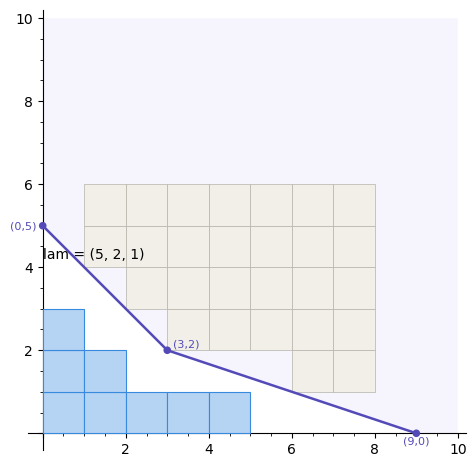

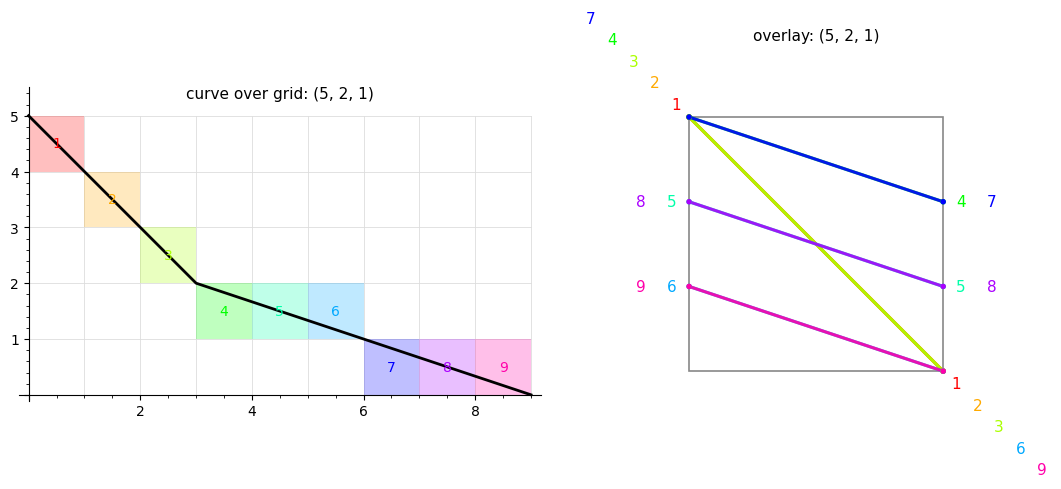

Braid word: [4, 5, 6, 7, 1, 2, 3, 8, 9]
List1: [0, 0, 0, 0, 1, 0, 0, 0, 0]
List2: [0, 0, 0, 0, 1]


In [18]:
#GETTING THE BRAID WORD AND THE TWO 0/1 SEQUENCES FOR A GIVEN PARTITION

partition = [5,2,1] #partition in french notation
details = concave_hull(partition, True) #get the details of the concave hull, True means we want to plot the concave hull
b_word = boundary_permutation(details, True) #get the braid word, True means we want to plot overlay
print("Braid word:", b_word)
l1, l2 = torus_sequences(details) #get the two 0/1 sequences
print("List1:", l1)
print("List2:", l2)

Torus Knot (braid polynomial):
  Term 0: coeff=1, list1=[0, 0, 0, 0, 1, 0, 0, 0, 0], list2=[0, 0, 0, 0, 1], word=[4, 3, 2, 1, 5, 4, 3, 2, 6, 5, 4, 3]
TorusKnot(list1=[0, 0, 0, 0, 1, 0, 0, 0, 0], list2=[0, 0, 0, 0, 1], braid=(1)*[s3*s2*s1*s0*s4*s3*s2*s1*s5*s4*s3*s2])
Before simplify: Torus Knot (braid polynomial):
  Term 0: coeff=1, list1=[0, 0, 0, 0, 1, 0, 0, 0, 0], list2=[0, 0, 0, 0, 1], word=[4, 3, 2, 1, 5, 4, 3, 2, 6, 5, 4, 3]


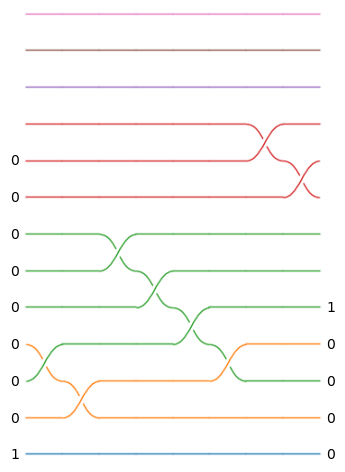

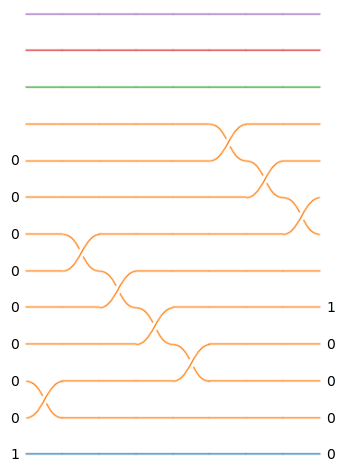

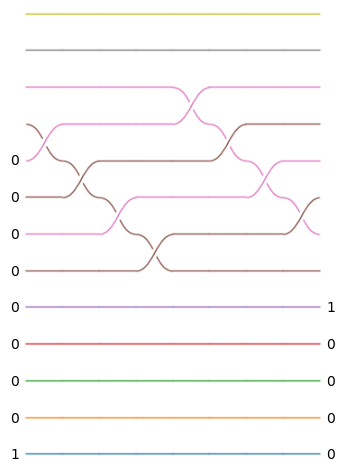

In [32]:
#SIMPLIFYING THE TORUS KNOT USING THE SIMPLIFICATION RULES
tk = TorusKnot(l1, l2, b_word, window=True) #b_word is window notation (a permutation); window=True converts it to a braid word
print(tk) #print the TorusKnot object
print(repr(tk)) #repr(tk) gives a more detailed representation of the TorusKnot object

import matplotlib.pyplot as plt
import math

# Grid layout: set ncols to the width you want; nrows grows to fit npanels.
#npanels = 5
#ncols = 2
#nrows = math.ceil(npanels / ncols)
#fig, axes = plt.subplots(nrows, ncols, figsize=(6 * ncols, 6 * nrows), squeeze=False)
#axes = axes.flatten()


print("Before simplify:", tk)
#tk.plot_braid()

tk.simplify_1_on_top()
#tk.plot_braid()

tk.simplify_1_on_top()
#tk.plot_braid()

tk.simplify_1_on_top()
#tk.plot_braid()

tk.simplify_1_on_top()
#tk.plot_braid()

tk.simplify_0s_vertical()
#tk.plot_braid()

tk.simplify_0s_vertical()
tk.plot_braid()

tk.simplify_0s_vertical()
tk.plot_braid()

tk.simplify_0s_vertical()
tk.simplify_0s_vertical()
tk.simplify_0s_vertical()
tk.simplify_0s_vertical()
tk.simplify_0s_vertical()
tk.plot_braid()